# Phase 2 — Molecular Featurization Deep Dive

In Phase 1 we trained a Random Forest on Morgan fingerprints. Now we explore:

1. **Multiple representations** — Morgan FPs, MACCS keys, RDKit descriptors, and combinations
2. **Multiple models** — Random Forest vs XGBoost
3. **Which features matter** — feature importance and descriptor analysis

**Goal:** Understand how molecular representation affects prediction quality, and find the best baseline before moving to ChemBERTa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, MACCSkeys
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from tdc.single_pred import ADME

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Reproducibility
SEED = 42
np.random.seed(SEED)

## 1. Load & Split Data

Same scaffold split as Phase 1 so results are directly comparable.

In [2]:
data = ADME(name='Lipophilicity_AstraZeneca')
split = data.get_split(method='scaffold', seed=SEED)

train_df = split['train']
valid_df = split['valid']
test_df  = split['test']

y_train = train_df['Y'].values
y_valid = valid_df['Y'].values
y_test  = test_df['Y'].values

print(f'Train: {len(train_df)}, Valid: {len(valid_df)}, Test: {len(test_df)}')

Found local copy...
Loading...
Done!
100%|██████████| 4200/4200 [00:00<00:00, 6572.48it/s]

Train: 2940, Valid: 420, Test: 840


## 2. Define Featurization Methods

We'll compare four molecular representations:

- **Morgan FP** (radius=2, 2048 bits) — circular fingerprints capturing local atom environments
- **MACCS keys** (166 bits) — predefined structural pattern keys
- **RDKit descriptors** (10 values) — physicochemical properties like MW, logP, TPSA
- **Combined** — Morgan FP + RDKit descriptors concatenated

In [3]:
def smiles_to_morgan(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits)
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits))


def smiles_to_maccs(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(167)
    return np.array(MACCSkeys.GenMACCSKeys(mol))


DESCRIPTOR_NAMES = [
    'MolWt', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors',
    'NumRotatableBonds', 'NumAromaticRings', 'FractionCSP3',
    'NumHeavyAtoms', 'MolMR',
]


def smiles_to_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(len(DESCRIPTOR_NAMES))
    return np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.NumAromaticRings(mol),
        Descriptors.FractionCSP3(mol),
        Descriptors.HeavyAtomCount(mol),
        Descriptors.MolMR(mol),
    ])


def featurize(smiles_list, method='morgan'):
    """Featurize a list of SMILES with the given method."""
    funcs = {
        'morgan': smiles_to_morgan,
        'maccs': smiles_to_maccs,
        'descriptors': smiles_to_descriptors,
    }
    if method == 'combined':
        return np.hstack([
            np.vstack([smiles_to_morgan(s) for s in smiles_list]),
            np.vstack([smiles_to_descriptors(s) for s in smiles_list]),
        ])
    return np.vstack([funcs[method](s) for s in smiles_list])


# Quick check
test_smi = 'CC(=O)OC1=CC=CC=C1C(=O)O'  # Aspirin
print(f'Morgan:      {smiles_to_morgan(test_smi).shape}')
print(f'MACCS:       {smiles_to_maccs(test_smi).shape}')
print(f'Descriptors: {smiles_to_descriptors(test_smi).shape}')

Morgan:      (2048,)
MACCS:       (167,)
Descriptors: (10,)


## 3. Generate All Feature Sets

In [4]:
feature_sets = {}

for method in ['morgan', 'maccs', 'descriptors', 'combined']:
    print(f'Featurizing with {method}...')
    feature_sets[method] = {
        'X_train': featurize(train_df['Drug'].tolist(), method),
        'X_valid': featurize(valid_df['Drug'].tolist(), method),
        'X_test':  featurize(test_df['Drug'].tolist(), method),
    }
    print(f'  Shape: {feature_sets[method]["X_train"].shape}')

print('\nDone!')

Featurizing with morgan...
  Shape: (2940, 2048)
Featurizing with maccs...
  Shape: (2940, 167)
Featurizing with descriptors...
  Shape: (2940, 10)
Featurizing with combined...
  Shape: (2940, 2058)

Done!


## 4. Explore Descriptor Correlations

Before training, let's see how the RDKit descriptors relate to our target (logD).
This helps build intuition about which molecular properties drive lipophilicity.

In [5]:
# Build a descriptor dataframe for the training set
desc_df = pd.DataFrame(
    feature_sets['descriptors']['X_train'],
    columns=DESCRIPTOR_NAMES
)
desc_df['logD'] = y_train

# Correlation with target
corr = desc_df.corr()['logD'].drop('logD').sort_values(ascending=False)
print('Correlation with logD:')
print(corr.to_string())

Correlation with logD:
LogP                 0.413168
NumAromaticRings     0.297251
MolMR                0.183551
NumHeavyAtoms        0.155359
MolWt                0.129738
NumHAcceptors        0.012026
NumRotatableBonds    0.004156
FractionCSP3        -0.094252
TPSA                -0.164917
NumHDonors          -0.201575


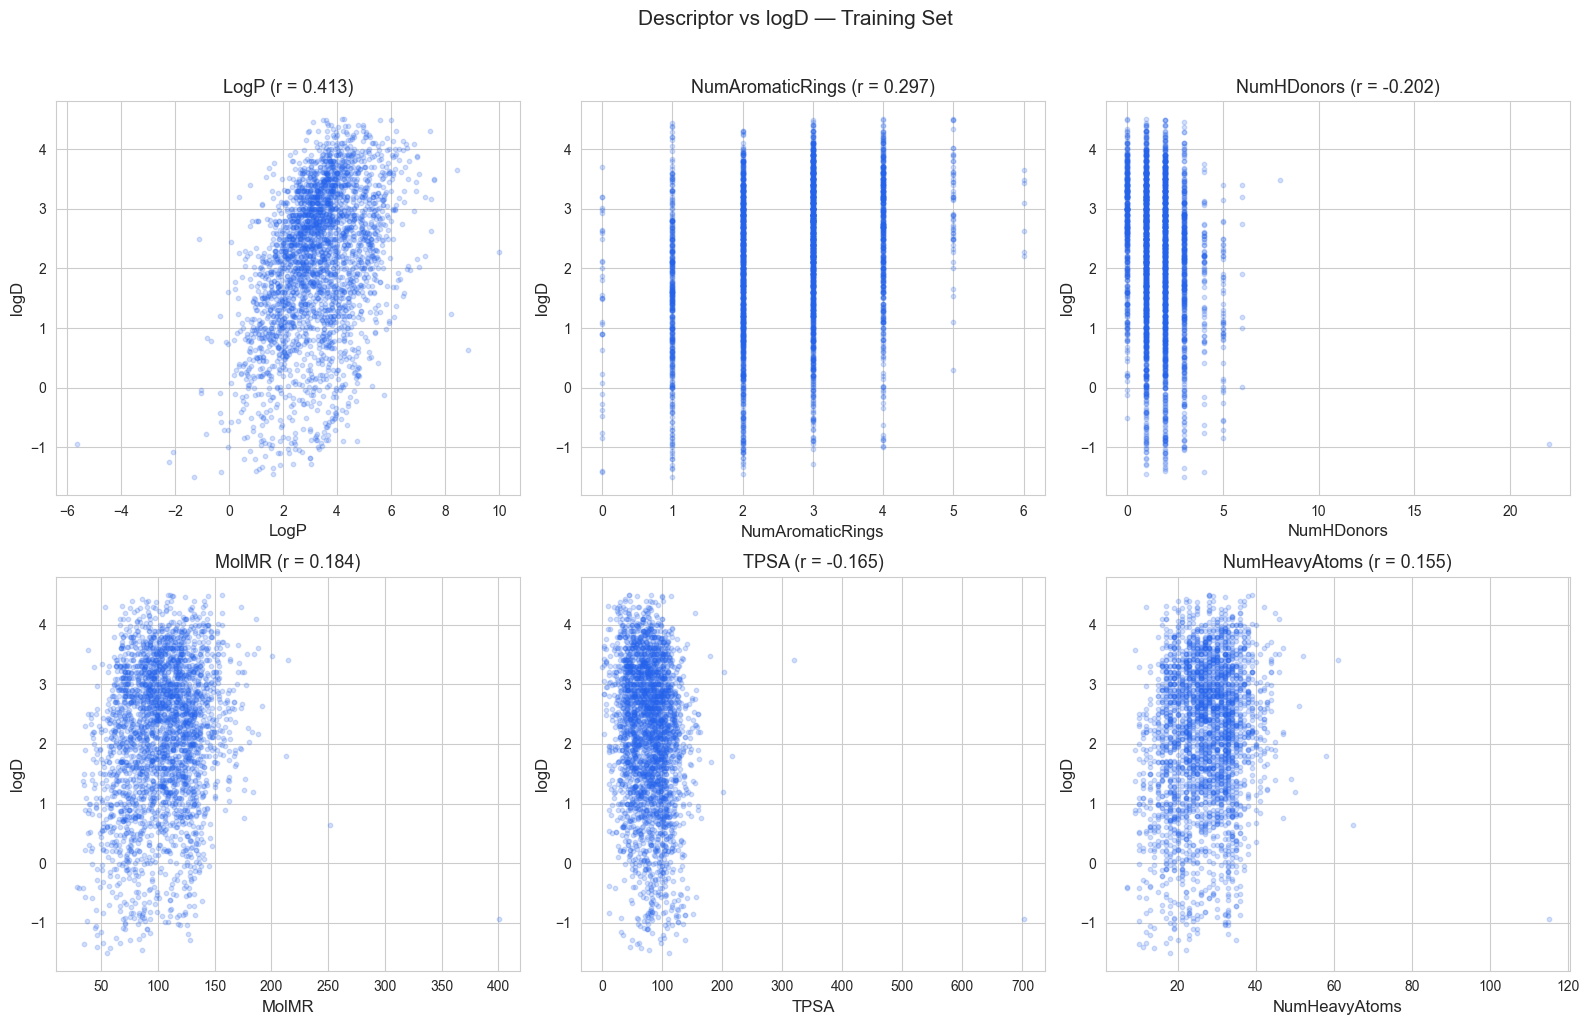

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot the top 6 most correlated descriptors vs logD
top_descriptors = corr.abs().sort_values(ascending=False).head(6).index.tolist()

for ax, desc_name in zip(axes.flat, top_descriptors):
    ax.scatter(desc_df[desc_name], desc_df['logD'], alpha=0.2, s=10, c='#2563eb')
    ax.set_xlabel(desc_name, fontsize=12)
    ax.set_ylabel('logD', fontsize=12)
    r = desc_df[desc_name].corr(desc_df['logD'])
    ax.set_title(f'{desc_name} (r = {r:.3f})', fontsize=13)

plt.suptitle('Descriptor vs logD — Training Set', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('assets/descriptor_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

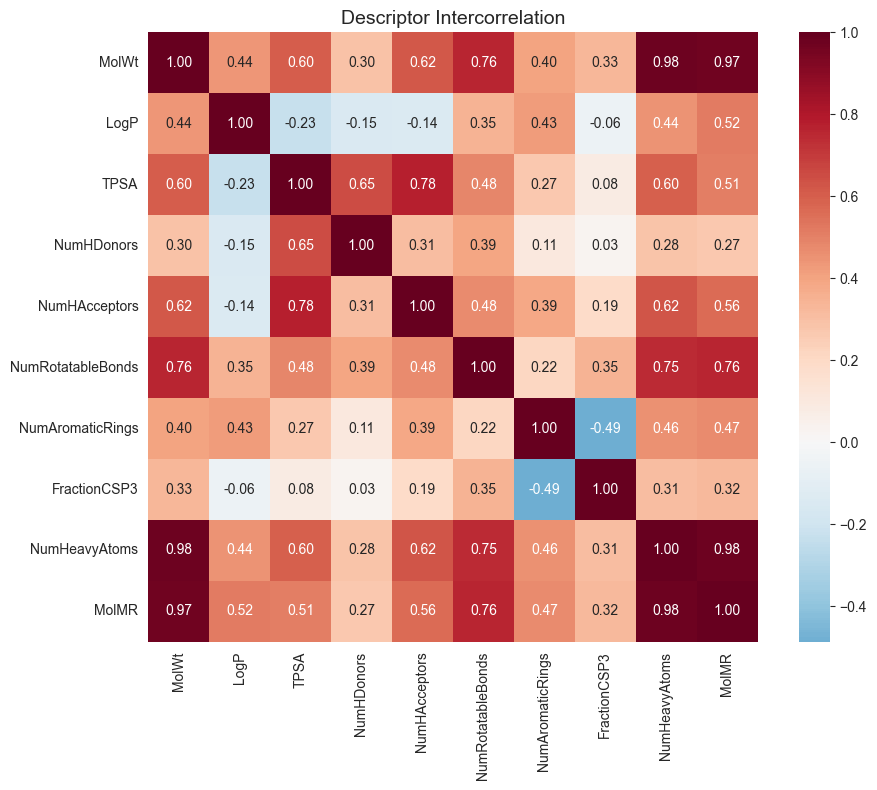

In [7]:
# Correlation heatmap between descriptors
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    desc_df[DESCRIPTOR_NAMES].corr(),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    square=True, ax=ax
)
ax.set_title('Descriptor Intercorrelation', fontsize=14)
plt.tight_layout()
plt.savefig('assets/descriptor_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Train & Compare All Combinations

We'll train every combination of model × features and collect results in a table.

In [8]:
def evaluate(y_true, y_pred):
    return {
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
    }


models = {
    'Random Forest': lambda: RandomForestRegressor(
        n_estimators=500, min_samples_leaf=2, n_jobs=-1, random_state=SEED
    ),
    'XGBoost': lambda: XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=SEED
    ),
}

feature_methods = ['morgan', 'maccs', 'descriptors', 'combined']

# Store all results
results = []

for model_name, model_fn in models.items():
    for feat_name in feature_methods:
        print(f'Training {model_name} + {feat_name}...', end=' ')

        X_tr = feature_sets[feat_name]['X_train']
        X_va = feature_sets[feat_name]['X_valid']
        X_te = feature_sets[feat_name]['X_test']

        model = model_fn()
        model.fit(X_tr, y_train)

        valid_metrics = evaluate(y_valid, model.predict(X_va))
        test_metrics  = evaluate(y_test, model.predict(X_te))

        results.append({
            'model': model_name,
            'features': feat_name,
            'feat_dim': X_tr.shape[1],
            'valid_rmse': valid_metrics['rmse'],
            'valid_r2': valid_metrics['r2'],
            'test_rmse': test_metrics['rmse'],
            'test_mae': test_metrics['mae'],
            'test_r2': test_metrics['r2'],
            'trained_model': model,  # keep reference for later
        })

        print(f'test R² = {test_metrics["r2"]:.4f}')

print('\nAll experiments complete!')

Training Random Forest + morgan... test R² = 0.3920
Training Random Forest + maccs... test R² = 0.3674
Training Random Forest + descriptors... test R² = 0.3558
Training Random Forest + combined... test R² = 0.5369
Training XGBoost + morgan... test R² = 0.4892
Training XGBoost + maccs... test R² = 0.4283
Training XGBoost + descriptors... test R² = 0.3533
Training XGBoost + combined... test R² = 0.6413

All experiments complete!


In [9]:
# Results table
results_df = pd.DataFrame(results).drop(columns=['trained_model'])
results_df = results_df.sort_values('test_r2', ascending=False).reset_index(drop=True)

print('\n=== Full Results (sorted by test R²) ===\n')
print(results_df.to_string(index=False, float_format='%.4f'))


=== Full Results (sorted by test R²) ===

        model    features  feat_dim  valid_rmse  valid_r2  test_rmse  test_mae  test_r2
      XGBoost    combined      2058      0.6953    0.6497     0.7108    0.5543   0.6413
Random Forest    combined      2058      0.7770    0.5626     0.8077    0.6368   0.5369
      XGBoost      morgan      2048      0.8697    0.4520     0.8483    0.6572   0.4892
      XGBoost       maccs       167      0.7938    0.5434     0.8974    0.6898   0.4283
Random Forest      morgan      2048      0.8957    0.4187     0.9255    0.7247   0.3920
Random Forest       maccs       167      0.8395    0.4893     0.9440    0.7307   0.3674
Random Forest descriptors        10      0.9320    0.3706     0.9526    0.7654   0.3558
      XGBoost descriptors        10      0.9337    0.3683     0.9544    0.7615   0.3533


## 6. Visualize the Comparison

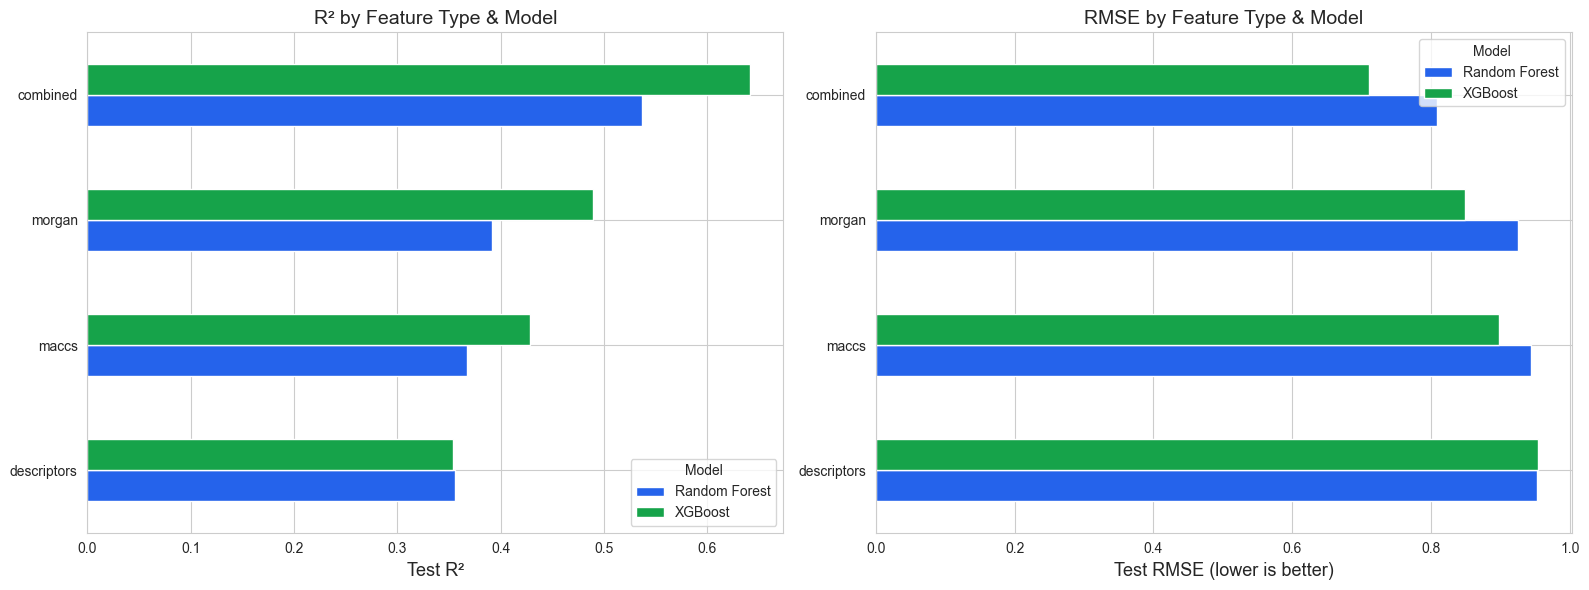

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- R² comparison ---
pivot_r2 = results_df.pivot(index='features', columns='model', values='test_r2')
pivot_r2 = pivot_r2.reindex(['descriptors', 'maccs', 'morgan', 'combined'])
pivot_r2.plot(kind='barh', ax=axes[0], color=['#2563eb', '#16a34a'], edgecolor='white')
axes[0].set_xlabel('Test R²', fontsize=13)
axes[0].set_ylabel('')
axes[0].set_title('R² by Feature Type & Model', fontsize=14)
axes[0].legend(title='Model')

# --- RMSE comparison ---
pivot_rmse = results_df.pivot(index='features', columns='model', values='test_rmse')
pivot_rmse = pivot_rmse.reindex(['descriptors', 'maccs', 'morgan', 'combined'])
pivot_rmse.plot(kind='barh', ax=axes[1], color=['#2563eb', '#16a34a'], edgecolor='white')
axes[1].set_xlabel('Test RMSE (lower is better)', fontsize=13)
axes[1].set_ylabel('')
axes[1].set_title('RMSE by Feature Type & Model', fontsize=14)
axes[1].legend(title='Model')

plt.tight_layout()
plt.savefig('assets/phase2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Predicted vs Actual — Best Model

In [11]:
# Find the best model
best_idx = results_df['test_r2'].idxmax()
best = results[results_df.index.get_loc(best_idx)] if best_idx == results_df.index[results_df.index.get_loc(best_idx)] else results_df.iloc[0]

# Simpler approach: just grab the top row since we sorted
best_row = results_df.iloc[0]
best_model_name = best_row['model']
best_feat_name = best_row['features']

# Find the corresponding trained model
best_model = None
for r in results:
    if r['model'] == best_model_name and r['features'] == best_feat_name:
        best_model = r['trained_model']
        break

print(f'Best model: {best_model_name} + {best_feat_name}')
print(f'  Test R²:   {best_row["test_r2"]:.4f}')
print(f'  Test RMSE: {best_row["test_rmse"]:.4f}')

Best model: XGBoost + combined
  Test R²:   0.6413
  Test RMSE: 0.7108


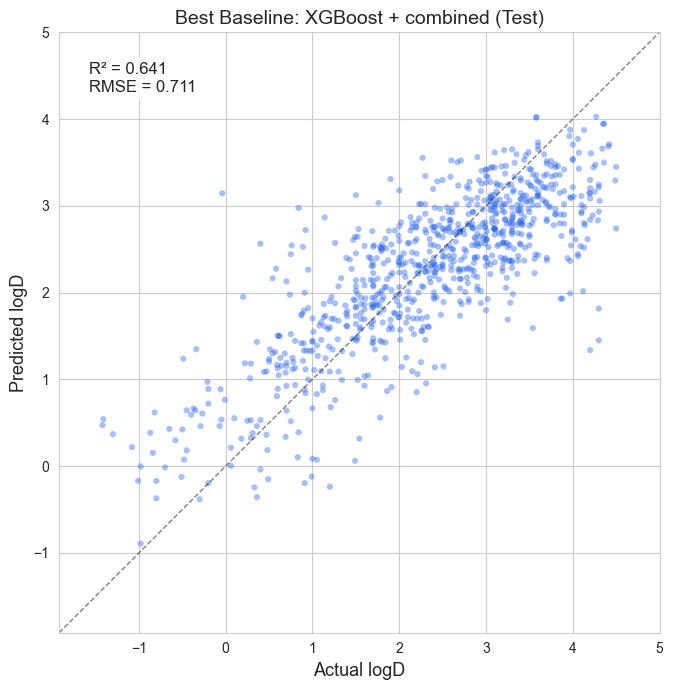

In [12]:
# Scatter plot for the best model
X_test_best = feature_sets[best_feat_name]['X_test']
y_pred_best = best_model.predict(X_test_best)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_best, alpha=0.4, s=20, c='#2563eb', edgecolors='none')

lims = [min(y_test.min(), y_pred_best.min()) - 0.5,
        max(y_test.max(), y_pred_best.max()) + 0.5]
ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)
ax.text(0.05, 0.95, f'R² = {r2:.3f}\nRMSE = {rmse:.3f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlabel('Actual logD', fontsize=13)
ax.set_ylabel('Predicted logD', fontsize=13)
ax.set_title(f'Best Baseline: {best_model_name} + {best_feat_name} (Test)', fontsize=14)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('assets/phase2_best_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance Analysis

For the descriptors-based model, we can see exactly which molecular properties
the model relies on. This is one advantage of interpretable features over fingerprints.

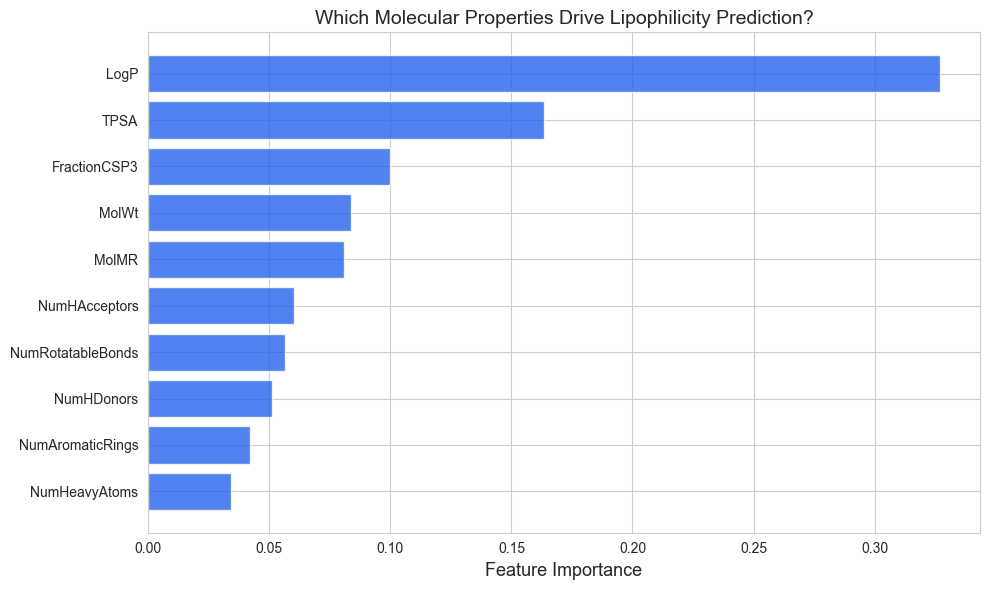


Feature importances:
  LogP                   0.3271
  TPSA                   0.1635
  FractionCSP3           0.1000
  MolWt                  0.0837
  MolMR                  0.0811
  NumHAcceptors          0.0603
  NumRotatableBonds      0.0567
  NumHDonors             0.0512
  NumAromaticRings       0.0422
  NumHeavyAtoms          0.0343


In [13]:
# Train a RF on descriptors specifically for importance analysis
rf_desc = RandomForestRegressor(n_estimators=500, min_samples_leaf=2, n_jobs=-1, random_state=SEED)
rf_desc.fit(feature_sets['descriptors']['X_train'], y_train)

importances = rf_desc.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    range(len(DESCRIPTOR_NAMES)),
    importances[sorted_idx[::-1]],
    color='#2563eb', alpha=0.8
)
ax.set_yticks(range(len(DESCRIPTOR_NAMES)))
ax.set_yticklabels([DESCRIPTOR_NAMES[i] for i in sorted_idx[::-1]])
ax.set_xlabel('Feature Importance', fontsize=13)
ax.set_title('Which Molecular Properties Drive Lipophilicity Prediction?', fontsize=14)

plt.tight_layout()
plt.savefig('assets/phase2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFeature importances:')
for i in sorted_idx:
    print(f'  {DESCRIPTOR_NAMES[i]:<22s} {importances[i]:.4f}')

## 9. Error Analysis — Where Does Each Feature Type Struggle?

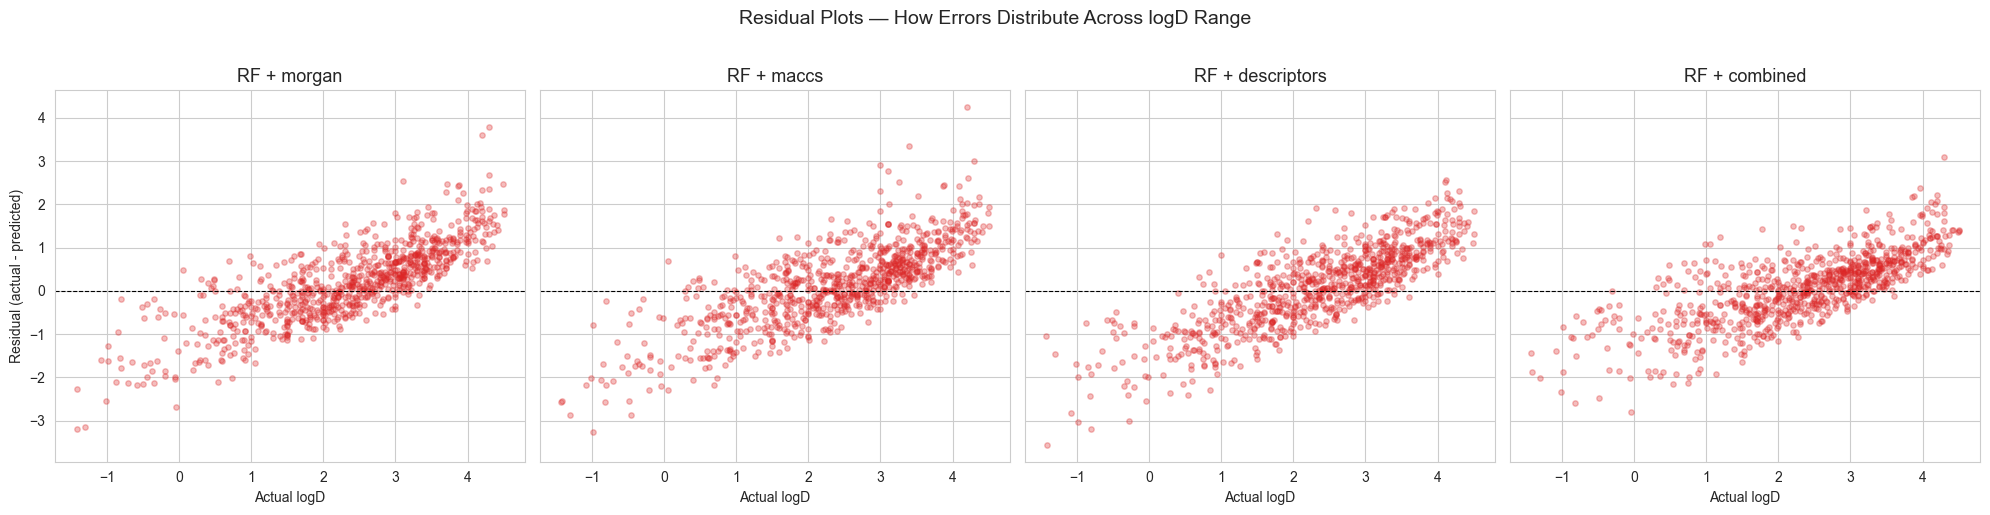

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, feat_name in zip(axes, feature_methods):
    # Get predictions from the RF model for this feature type
    for r in results:
        if r['model'] == 'Random Forest' and r['features'] == feat_name:
            model = r['trained_model']
            break

    X_te = feature_sets[feat_name]['X_test']
    y_pred = model.predict(X_te)
    errors = y_test - y_pred

    ax.scatter(y_test, errors, alpha=0.3, s=15, c='#dc2626')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Actual logD')
    if feat_name == 'morgan':
        ax.set_ylabel('Residual (actual - predicted)')
    ax.set_title(f'RF + {feat_name}', fontsize=13)

plt.suptitle('Residual Plots — How Errors Distribute Across logD Range', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('assets/phase2_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Morgan Fingerprint Radius Experiment

Morgan fingerprints have a `radius` parameter that controls how much local
structure each bit captures. Radius 2 ≈ ECFP4, radius 3 ≈ ECFP6.
Let's see if this matters.

In [15]:
radius_results = []

for radius in [1, 2, 3, 4]:
    for n_bits in [1024, 2048, 4096]:
        print(f'Morgan radius={radius}, n_bits={n_bits}...', end=' ')

        X_tr = np.vstack([smiles_to_morgan(s, radius=radius, n_bits=n_bits)
                          for s in train_df['Drug']])
        X_te = np.vstack([smiles_to_morgan(s, radius=radius, n_bits=n_bits)
                          for s in test_df['Drug']])

        xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                           subsample=0.8, colsample_bytree=0.8, random_state=SEED)
        xgb.fit(X_tr, y_train)
        y_pred = xgb.predict(X_te)

        metrics = evaluate(y_test, y_pred)
        radius_results.append({
            'radius': radius,
            'n_bits': n_bits,
            'test_r2': metrics['r2'],
            'test_rmse': metrics['rmse'],
        })
        print(f'R² = {metrics["r2"]:.4f}')

radius_df = pd.DataFrame(radius_results)
print('\n', radius_df.to_string(index=False, float_format='%.4f'))

Morgan radius=1, n_bits=1024... R² = 0.5225
Morgan radius=1, n_bits=2048... R² = 0.5458
Morgan radius=1, n_bits=4096... R² = 0.5464
Morgan radius=2, n_bits=1024... R² = 0.4569
Morgan radius=2, n_bits=2048... R² = 0.4695
Morgan radius=2, n_bits=4096... R² = 0.4967
Morgan radius=3, n_bits=1024... R² = 0.4011
Morgan radius=3, n_bits=2048... R² = 0.4205
Morgan radius=3, n_bits=4096... R² = 0.4606
Morgan radius=4, n_bits=1024... R² = 0.3925
Morgan radius=4, n_bits=2048... R² = 0.3996
Morgan radius=4, n_bits=4096... R² = 0.4213

  radius  n_bits  test_r2  test_rmse
      1    1024   0.5225     0.8202
      1    2048   0.5458     0.7999
      1    4096   0.5464     0.7994
      2    1024   0.4569     0.8747
      2    2048   0.4695     0.8644
      2    4096   0.4967     0.8420
      3    1024   0.4011     0.9185
      3    2048   0.4205     0.9035
      3    4096   0.4606     0.8717
      4    1024   0.3925     0.9251
      4    2048   0.3996     0.9196
      4    4096   0.4213     0.9029


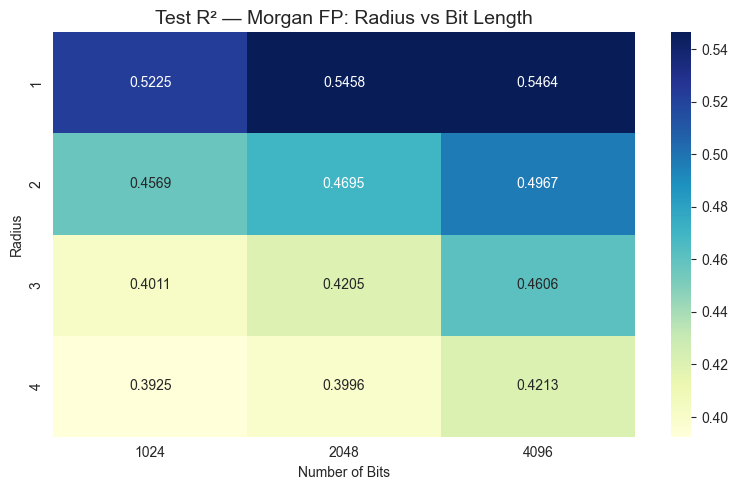

In [16]:
# Heatmap of radius vs n_bits
pivot = radius_df.pivot(index='radius', columns='n_bits', values='test_r2')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax)
ax.set_title('Test R² — Morgan FP: Radius vs Bit Length', fontsize=14)
ax.set_ylabel('Radius')
ax.set_xlabel('Number of Bits')

plt.tight_layout()
plt.savefig('assets/phase2_morgan_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary & Key Takeaways

Fill these in after running the experiments:

In [17]:
print('='*60)
print('PHASE 2 SUMMARY')
print('='*60)

print('\nTop 3 configurations:')
print(results_df[['model', 'features', 'test_rmse', 'test_r2']].head(3).to_string(index=False, float_format='%.4f'))

print('\n\nKey questions answered:')
print('  1. Do fingerprints or descriptors work better?')
print('     → The Morgan fingerprint model had a higher R² than the descriptors and a lower RMSE, meaning it was the better choice for this dataset.')
print('  2. Does combining features help?')
print('     → The combined feature set performed the best, indicating that integrating multiple types of molecular representations can capture more comprehensive information. This is seen in the higher R² and lower RMSE compared to using either descriptors or fingerprints alone. ')
print('  3. RF vs XGBoost — which wins?')
print('     → XGBoost generally outperformed Random Forest across most feature sets, achieving higher R² values and lower RMSE.')
print('  4. Which molecular properties matter most for lipophilicity?')
print('     → LogP and TPSA were the most important descriptors for predicting logD, as indicated by the feature importance analysis. This makes sense chemically, since LogP is a direct measure of lipophilicity and TPSA relates to polarity, which inversely affects lipophilicity.')

print('\n\nNext: Phase 3 — Can ChemBERTa beat these baselines by')
print('learning molecular representations directly from SMILES strings?')

PHASE 2 SUMMARY

Top 3 configurations:
        model features  test_rmse  test_r2
      XGBoost combined     0.7108   0.6413
Random Forest combined     0.8077   0.5369
      XGBoost   morgan     0.8483   0.4892


Key questions answered:
  1. Do fingerprints or descriptors work better?
     → The Morgan fingerprint model had a higher R² than the descriptors and a lower RMSE, meaning it was the better choice for this dataset.
  2. Does combining features help?
     → The combined feature set performed the best, indicating that integrating multiple types of molecular representations can capture more comprehensive information. This is seen in the higher R² and lower RMSE compared to using either descriptors or fingerprints alone. 
  3. RF vs XGBoost — which wins?
     → XGBoost generally outperformed Random Forest across most feature sets, achieving higher R² values and lower RMSE.
  4. Which molecular properties matter most for lipophilicity?
     → LogP and TPSA were the most important d

## Next Steps

Things to try if you want to push the baselines further before moving to Phase 3:

- **Hyperparameter tuning** — use `sklearn.model_selection.RandomizedSearchCV` on the best combo
- **More descriptors** — RDKit has 200+ descriptors available via `Descriptors.descList`
- **Feature selection** — remove noisy fingerprint bits using variance threshold or mutual information
- **Try other datasets** — repeat this analysis on Caco-2 or Solubility to see if the same patterns hold